<a href="https://colab.research.google.com/github/jumanazez/DSproject/blob/main/cleaned_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Processing and Cleaning**
**Load the Raw Data**

The raw data was collected from the YouTube API and stored in JSON files. The files were loaded and combined into one DataFrame for processing.

The raw data was kept unchanged so that the original dataset remains available for reference.

In [172]:
import pandas as pd
import json
import glob
import os

files = glob.glob("/content/*.json")

all_data = []

for file in files:
    with open(file, "r", encoding="utf-8") as f:
        data = json.load(f)

    df = pd.json_normalize(data)

    # Identify podcast name from the file name
    file_name = os.path.basename(file).lower()

    if "fanjan" in file_name:
        df["podcast"] = "Fanjan"
    elif "socrates" in file_name:
        df["podcast"] = "Socrates"
    elif "swalif" in file_name:
        df["podcast"] = "Swalif Business"
    elif "mortada" in file_name:
        df["podcast"] = "Mortada"
    else:
        continue

    all_data.append(df)

combined_df = pd.concat(all_data, ignore_index=True)

combined_df.head()

,kind,etag,id,snippet.publishedAt,snippet.channelId,snippet.title,snippet.description,snippet.thumbnails.default.url,snippet.thumbnails.default.width,snippet.thumbnails.default.height,...,contentDetails.projection,statistics.viewCount,statistics.likeCount,statistics.favoriteCount,statistics.commentCount,snippet.tags,podcast,snippet.thumbnails.fhd.url,snippet.thumbnails.fhd.width,snippet.thumbnails.fhd.height
0,youtube#video,5xVJtOimxAjs2IOgFCEp2_wDtkY,HZKdvcoyzwI,2026-01-19T12:00:18Z,UCwjLh640nGXSGa9iHRS31ag,كيف تضمن الشركات استدامتها | بودكاست سوالف بزنس,هناك أكثر من مليون منشأة فعّالة في السعودية، م...,https://i.ytimg.com/vi/HZKdvcoyzwI/default.jpg,120,90,...,rectangular,135283,1729,0,53,NaN,Swalif Business,NaN,NaN,NaN
1,youtube#video,jXJXQaLVuURW-k7v4uJxqg1uwmg,DA0oZJ8Ly-8,2025-11-24T15:02:36Z,UCwjLh640nGXSGa9iHRS31ag,كيف تستفيد من الذكاء الاصطناعي في شركتك | بودك...,وسط موجة المبالغة والترويج المفرط للذكاء الاصط...,https://i.ytimg.com/vi/DA0oZJ8Ly-8/default.jpg,120,90,...,rectangular,98130,1220,0,176,NaN,Swalif Business,NaN,NaN,NaN
2,youtube#video,yxfasNpwWiifIKLQQwRNlxJK_Xg,YI5PVi26Ixg,2025-11-18T13:01:09Z,UCwjLh640nGXSGa9iHRS31ag,كيف تعمل شركات تصنيع المكياج | بودكاست سوالف بزنس,برزت في السنوات الأخيرة علامات تجارية في عالم ...,https://i.ytimg.com/vi/YI5PVi26Ixg/default.jpg,120,90,...,rectangular,39131,508,0,112,NaN,Swalif Business,NaN,NaN,NaN
3,youtube#video,Z9bx0YcZqvi3TILEpF7UYhTTOjM,t7IrlGQ3aPM,2025-11-10T15:01:42Z,UCwjLh640nGXSGa9iHRS31ag,أين الفرص الاستثمارية في قطاع الصناعات العسكري...,نستضيف في هذه الحلقة بدر المصيبيح، المدير العا...,https://i.ytimg.com/vi/t7IrlGQ3aPM/default.jpg,120,90,...,rectangular,90831,1227,0,170,NaN,Swalif Business,NaN,NaN,NaN
4,youtube#video,L_kO9d9a-BK9WxQwOhXS0NqLAcQ,JzQJahCyZcw,2025-11-03T19:36:00Z,UCwjLh640nGXSGa9iHRS31ag,كيف نجح تطبيق توصيل سوري رغم الحرب والعقوبات |...,هذه الحلقة مختلفة تمامًا عن الحلقات السابقة، م...,https://i.ytimg.com/vi/JzQJahCyZcw/default.jpg,120,90,...,rectangular,35332,543,0,199,NaN,Swalif Business,NaN,NaN,NaN


In [173]:
print("Shape:", combined_df.shape)

print("\nPodcast counts:")
print(combined_df["podcast"].value_counts())

print("\nTotal videos:", combined_df["podcast"].value_counts().sum())

Shape: (701, 44)

Podcast counts:
podcast
Fanjan             257
Socrates           181
Swalif Business    147
Mortada            116
Name: count, dtype: int64

Total videos: 701


In [174]:
combined_df.to_csv(
    "combined_raw_data.csv",
    index=False,
    encoding="utf-8-sig"
)

In [175]:
combined_df.shape

(701, 44)

In [176]:
df = pd.read_csv("combined_raw_data.csv")

**Initial Data Inspection:**

The combined dataset was inspected before cleaning to identify its dimensions, data types, missing values, and duplicate records

The dataset contains 701 records and 43 columns.

We also checked the dataset for missing values and identified columns with a large number of missing values, such as thumbnail and tag-related fields.

In [177]:
df.columns.tolist()

['kind',
 'etag',
 'id',
 'snippet.publishedAt',
 'snippet.channelId',
 'snippet.title',
 'snippet.description',
 'snippet.thumbnails.default.url',
 'snippet.thumbnails.default.width',
 'snippet.thumbnails.default.height',
 'snippet.thumbnails.medium.url',
 'snippet.thumbnails.medium.width',
 'snippet.thumbnails.medium.height',
 'snippet.thumbnails.high.url',
 'snippet.thumbnails.high.width',
 'snippet.thumbnails.high.height',
 'snippet.thumbnails.standard.url',
 'snippet.thumbnails.standard.width',
 'snippet.thumbnails.standard.height',
 'snippet.thumbnails.maxres.url',
 'snippet.thumbnails.maxres.width',
 'snippet.thumbnails.maxres.height',
 'snippet.channelTitle',
 'snippet.categoryId',
 'snippet.liveBroadcastContent',
 'snippet.defaultLanguage',
 'snippet.localized.title',
 'snippet.localized.description',
 'snippet.defaultAudioLanguage',
 'contentDetails.duration',
 'contentDetails.dimension',
 'contentDetails.definition',
 'contentDetails.caption',
 'contentDetails.licensedConten

In [178]:
df.head()

,kind,etag,id,snippet.publishedAt,snippet.channelId,snippet.title,snippet.description,snippet.thumbnails.default.url,snippet.thumbnails.default.width,snippet.thumbnails.default.height,...,contentDetails.projection,statistics.viewCount,statistics.likeCount,statistics.favoriteCount,statistics.commentCount,snippet.tags,podcast,snippet.thumbnails.fhd.url,snippet.thumbnails.fhd.width,snippet.thumbnails.fhd.height
0,youtube#video,5xVJtOimxAjs2IOgFCEp2_wDtkY,HZKdvcoyzwI,2026-01-19T12:00:18Z,UCwjLh640nGXSGa9iHRS31ag,كيف تضمن الشركات استدامتها | بودكاست سوالف بزنس,هناك أكثر من مليون منشأة فعّالة في السعودية، م...,https://i.ytimg.com/vi/HZKdvcoyzwI/default.jpg,120,90,...,rectangular,135283,1729,0,53,NaN,Swalif Business,NaN,NaN,NaN
1,youtube#video,jXJXQaLVuURW-k7v4uJxqg1uwmg,DA0oZJ8Ly-8,2025-11-24T15:02:36Z,UCwjLh640nGXSGa9iHRS31ag,كيف تستفيد من الذكاء الاصطناعي في شركتك | بودك...,وسط موجة المبالغة والترويج المفرط للذكاء الاصط...,https://i.ytimg.com/vi/DA0oZJ8Ly-8/default.jpg,120,90,...,rectangular,98130,1220,0,176,NaN,Swalif Business,NaN,NaN,NaN
2,youtube#video,yxfasNpwWiifIKLQQwRNlxJK_Xg,YI5PVi26Ixg,2025-11-18T13:01:09Z,UCwjLh640nGXSGa9iHRS31ag,كيف تعمل شركات تصنيع المكياج | بودكاست سوالف بزنس,برزت في السنوات الأخيرة علامات تجارية في عالم ...,https://i.ytimg.com/vi/YI5PVi26Ixg/default.jpg,120,90,...,rectangular,39131,508,0,112,NaN,Swalif Business,NaN,NaN,NaN
3,youtube#video,Z9bx0YcZqvi3TILEpF7UYhTTOjM,t7IrlGQ3aPM,2025-11-10T15:01:42Z,UCwjLh640nGXSGa9iHRS31ag,أين الفرص الاستثمارية في قطاع الصناعات العسكري...,نستضيف في هذه الحلقة بدر المصيبيح، المدير العا...,https://i.ytimg.com/vi/t7IrlGQ3aPM/default.jpg,120,90,...,rectangular,90831,1227,0,170,NaN,Swalif Business,NaN,NaN,NaN
4,youtube#video,L_kO9d9a-BK9WxQwOhXS0NqLAcQ,JzQJahCyZcw,2025-11-03T19:36:00Z,UCwjLh640nGXSGa9iHRS31ag,كيف نجح تطبيق توصيل سوري رغم الحرب والعقوبات |...,هذه الحلقة مختلفة تمامًا عن الحلقات السابقة، م...,https://i.ytimg.com/vi/JzQJahCyZcw/default.jpg,120,90,...,rectangular,35332,543,0,199,NaN,Swalif Business,NaN,NaN,NaN


In [179]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 701 entries, 0 to 700
Data columns (total 44 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   kind                                701 non-null    object 
 1   etag                                701 non-null    object 
 2   id                                  701 non-null    object 
 3   snippet.publishedAt                 701 non-null    object 
 4   snippet.channelId                   701 non-null    object 
 5   snippet.title                       701 non-null    object 
 6   snippet.description                 701 non-null    object 
 7   snippet.thumbnails.default.url      701 non-null    object 
 8   snippet.thumbnails.default.width    701 non-null    int64  
 9   snippet.thumbnails.default.height   701 non-null    int64  
 10  snippet.thumbnails.medium.url       701 non-null    object 
 11  snippet.thumbnails.medium.width     701 non-n

In [180]:
df.isnull().sum()

,0
kind,0
etag,0
id,0
snippet.publishedAt,0
snippet.channelId,0
snippet.title,0
snippet.description,0
snippet.thumbnails.default.url,0
snippet.thumbnails.default.width,0
snippet.thumbnails.default.height,0


In [181]:
df["id"].duplicated().sum()

np.int64(0)

**3. Feature Selection**

**We removed** :

Channel information because all videos belong to the same channel.

Language information because it is not relevant to our analysis.

Caption information because it is not needed for the research question.

**Podcast** was retained to identify the program associated with each episode and to support podcast-level comparisons during exploratory data analysis.

Tags because we will use the video titles to identify and analyze topics.

API metadata and unnecessary thumbnail information because they are not needed for the analysis.

In [182]:
print(df.columns.tolist())

['kind', 'etag', 'id', 'snippet.publishedAt', 'snippet.channelId', 'snippet.title', 'snippet.description', 'snippet.thumbnails.default.url', 'snippet.thumbnails.default.width', 'snippet.thumbnails.default.height', 'snippet.thumbnails.medium.url', 'snippet.thumbnails.medium.width', 'snippet.thumbnails.medium.height', 'snippet.thumbnails.high.url', 'snippet.thumbnails.high.width', 'snippet.thumbnails.high.height', 'snippet.thumbnails.standard.url', 'snippet.thumbnails.standard.width', 'snippet.thumbnails.standard.height', 'snippet.thumbnails.maxres.url', 'snippet.thumbnails.maxres.width', 'snippet.thumbnails.maxres.height', 'snippet.channelTitle', 'snippet.categoryId', 'snippet.liveBroadcastContent', 'snippet.defaultLanguage', 'snippet.localized.title', 'snippet.localized.description', 'snippet.defaultAudioLanguage', 'contentDetails.duration', 'contentDetails.dimension', 'contentDetails.definition', 'contentDetails.caption', 'contentDetails.licensedContent', 'contentDetails.projection', 

In [183]:
keep_columns = [
    "id",
    "podcast",
    "snippet.publishedAt",
    "snippet.title",
    "snippet.description",
    "snippet.categoryId",
    "contentDetails.duration",
    "statistics.viewCount",
    "statistics.likeCount",
    "statistics.commentCount",
]

df_clean = df[keep_columns].copy()

4. **Rename Columns**

The remaining columns were renamed to simpler names to make the dataset easier to understand and use in Python.


In [184]:
df_clean = df_clean.rename(columns={
    "id": "video_id",
    "snippet.publishedAt": "published_at",
    "snippet.title": "title",
    "snippet.description": "description",
    "snippet.categoryId": "category_id",
    "contentDetails.duration": "duration",
    "statistics.viewCount": "views",
    "statistics.likeCount": "likes",
    "statistics.commentCount": "comments",
})

**6. Convert Data Types**

The publication date was converted from text into a datetime format so that it can be used for time-based analysis.

The views, likes, and comments were kept as numerical values for statistical analysis.

In [185]:
df_clean["published_at"] = pd.to_datetime(
    df_clean["published_at"],
    errors="coerce"
)


7. **Process Video Duration**

The original duration is stored in YouTube's ISO 8601 format, such as PT1H20M35S.

The duration was converted into minutes to make it easier to analyze whether video length is related to views or audience engagement.

In [186]:
import re

def duration_to_minutes(duration):
    hours = re.search(r'(\d+)H', duration)
    minutes = re.search(r'(\d+)M', duration)
    seconds = re.search(r'(\d+)S', duration)

    h = int(hours.group(1)) if hours else 0
    m = int(minutes.group(1)) if minutes else 0
    s = int(seconds.group(1)) if seconds else 0

    return h * 60 + m + s / 60

df_clean["duration_minutes"] = (
    df_clean["duration"].apply(duration_to_minutes)
)

**8. Create Time Features**
Additional time-related features were created from the publication date, including:

Year
Month
Day of the week

The day of the week was added to examine whether the publication day is related to views and audience engagement.

These features can help us explore changes in views and engagement over time.

In [187]:
df_clean["year"] = df_clean["published_at"].dt.year
df_clean["month"] = df_clean["published_at"].dt.month

df_clean["day_of_week"] = df_clean["published_at"].dt.day_name()

**9. Calculate Engagement Rate**

Engagement rate measures how much the audience interacts with a video compared to the number of views.

It was calculated using likes and comments:

Engagement Rate = (Likes + Comments) / Views × 100

This metric allows us to compare audience engagement between videos with different numbers of views.

In [188]:
df_clean[["views", "likes", "comments"]].describe()


,views,likes,comments
count,7.010000e+02,7.010000e+02,701.000000
mean,8.338538e+05,9.928528e+03,672.901569
std,6.455122e+06,8.202404e+04,2655.179801
min,1.656200e+04,1.980000e+02,0.000000
25%,7.682200e+04,1.072000e+03,112.000000
50%,1.440850e+05,2.084000e+03,216.000000
75%,4.425370e+05,5.873000e+03,569.000000
max,1.624105e+08,2.137322e+06,63697.000000


In [189]:
(df_clean[["views", "likes", "comments"]] < 0).sum()
(df_clean["views"] == 0).sum()

np.int64(0)

In [190]:
df_clean["engagement_rate"] = (
    (df_clean["likes"] + df_clean["comments"])
    / df_clean["views"]
) * 100

## 10. Final Dataset Check

After cleaning and processing, the dataset was checked again to ensure:

- No missing values
- No duplicate video records
- Correct data types
- Relevant features were retained
- Valid numerical values
- Each episode was correctly associated with its podcast program

The final cleaned dataset contains **701 videos and 15 features**, including the `podcast` variable, which identifies whether each episode belongs to **Fanjan, Socrates, Swalif Business, or Mortada**.

The cleaned dataset is now ready for **Exploratory Data Analysis (EDA)**.

In [191]:
df_clean.info()
df_clean.isnull().sum()
df_clean.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 701 entries, 0 to 700
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   video_id          701 non-null    object             
 1   podcast           701 non-null    object             
 2   published_at      701 non-null    datetime64[ns, UTC]
 3   title             701 non-null    object             
 4   description       701 non-null    object             
 5   category_id       701 non-null    int64              
 6   duration          701 non-null    object             
 7   views             701 non-null    int64              
 8   likes             701 non-null    int64              
 9   comments          701 non-null    int64              
 10  duration_minutes  701 non-null    float64            
 11  year              701 non-null    int32              
 12  month             701 non-null    int32              
 13  day_o

np.int64(0)

## 11. Save the Cleaned Dataset as a CSV File
The final cleaned and processed dataset was saved as a CSV file for use in the Exploratory Data Analysis (EDA) stage.

In [192]:
df_clean.to_csv(
    "/content/thmanyah_cleaned_dataset.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Cleaned dataset saved successfully!")
print("Shape:", df_clean.shape)

Cleaned dataset saved successfully!
Shape: (701, 15)


# Exploratory Data Analysis (EDA) – Primary Data

This section explores the cleaned primary YouTube dataset to identify general patterns, distributions, trends, and anomalies in audience reach and engagement across the selected Thmanyah podcasts.

## 1. Dataset Overview

Before performing the statistical and visual analysis, the cleaned dataset was reviewed to understand its size, variables, and distribution of episodes across the selected podcast programs.

In [193]:
print("Dataset shape:", df_clean.shape)

print("\nNumber of episodes per podcast:")
print(df_clean["podcast"].value_counts())

print("\nDataset columns:")
print(df_clean.columns.tolist())

Dataset shape: (701, 15)

Number of episodes per podcast:
podcast
Fanjan             257
Socrates           181
Swalif Business    147
Mortada            116
Name: count, dtype: int64

Dataset columns:
['video_id', 'podcast', 'published_at', 'title', 'description', 'category_id', 'duration', 'views', 'likes', 'comments', 'duration_minutes', 'year', 'month', 'day_of_week', 'engagement_rate']


### Initial Observation

The cleaned dataset contains **701 episodes and 15 features** across four Thmanyah podcast programs. **Fanjan** has the largest number of episodes with 257, followed by **Socrates** with 181, **Swalif Business** with 147, and **Mortada** with 116.

This shows that the dataset is not evenly distributed across the four podcasts. Therefore, differences in the total number of views, likes, or comments between podcasts should be interpreted carefully, since podcasts with more episodes may naturally accumulate higher total engagement.

## 2. Descriptive Statistics

Descriptive statistics were calculated for the main numerical variables related to audience reach, engagement, and episode duration. These statistics provide an overview of the central tendency, spread, and range of the data before examining their distributions visually.

In [194]:
numerical_features = [
    "views",
    "likes",
    "comments",
    "duration_minutes",
    "engagement_rate"
]

df_clean[numerical_features].describe().round(2)

,views,likes,comments,duration_minutes,engagement_rate
count,7.010000e+02,701.00,701.00,701.00,701.00
mean,8.338538e+05,9928.53,672.90,102.47,1.61
std,6.455122e+06,82024.04,2655.18,31.87,0.64
min,1.656200e+04,198.00,0.00,0.68,0.16
25%,7.682200e+04,1072.00,112.00,80.90,1.18
50%,1.440850e+05,2084.00,216.00,97.75,1.58
75%,4.425370e+05,5873.00,569.00,117.57,1.94
max,1.624105e+08,2137322.00,63697.00,255.82,6.27


### Key Observations

- **Views:** The mean is approximately **833,854**, while the median is approximately **144,085**.
- **Likes:** The mean is approximately **9,929**, compared with a median of **2,084**.
- **Comments:** The mean is approximately **673**, while the median is **216**.
- **Duration:** The mean episode duration is approximately **102.47 minutes**, and the median is **97.75 minutes**.
- **Engagement Rate:** The mean is approximately **1.61%**, while the median is **1.58%**.

The large differences between the mean and median for **views, likes, and comments** suggest that these variables may be **right-skewed**, with a small number of highly popular episodes pulling the averages upward. This is especially noticeable for views, where the maximum reaches **162,410,500**, compared with a median of only **144,085**.

In contrast, **duration and engagement rate** have relatively similar mean and median values, suggesting more balanced distributions compared with views, likes, and comments.

### Descriptive Statistics – Initial Findings

The descriptive statistics show substantial variation in audience reach and engagement across the 701 episodes.

The average number of views is approximately **833,854**, while the median is only **144,085**. Similar differences are observed for likes and comments, where the means are noticeably higher than their medians. This suggests that the distributions of these engagement variables are likely **right-skewed**, with a relatively small number of highly popular episodes receiving substantially greater engagement than typical episodes.

Episode duration is more stable, with a mean of approximately **102.47 minutes** and a median of **97.75 minutes**. The engagement rate also shows relatively similar mean and median values, at approximately **1.61%** and **1.58%**, respectively.

The large maximum values, particularly for views, likes, and comments, indicate the possible presence of **extreme high-performing episodes**. These patterns will be examined further using distribution visualizations.

## 3. Distribution of Views

The distribution of episode views was examined to understand how audience reach varies across the dataset and to identify possible skewness and extreme values.

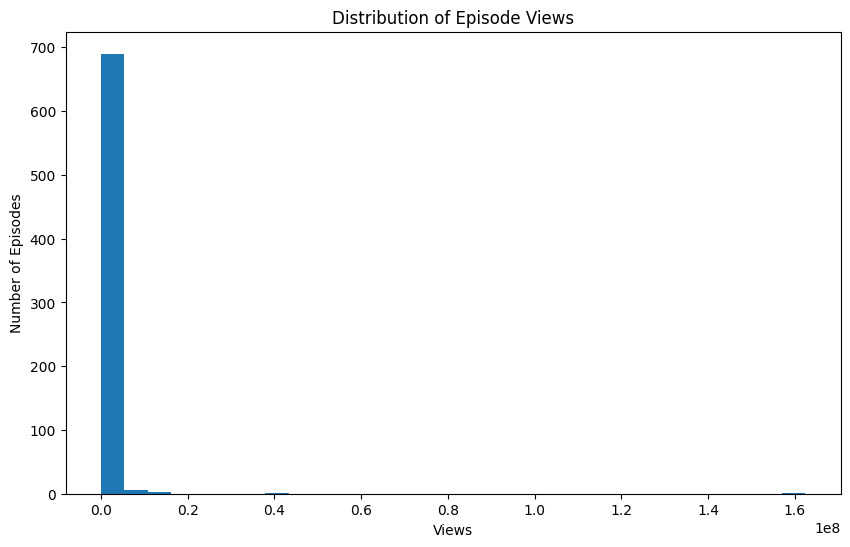

In [195]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(df_clean["views"], bins=30)

plt.title("Distribution of Episode Views")
plt.xlabel("Views")
plt.ylabel("Number of Episodes")

plt.show()

### Observation

The distribution of episode views is **strongly right-skewed**. Most episodes are concentrated at relatively lower view counts, while a small number of episodes have exceptionally high numbers of views.

The extreme values, including a maximum of approximately **162.4 million views**, stretch the x-axis and make the distribution of the majority of episodes difficult to observe in the original scale. This confirms the pattern observed in the descriptive statistics, where the mean number of views was substantially higher than the median.

### Views Distribution Using Log Transformation

Because the original distribution is strongly right-skewed, a **log10 transformation** was applied to the view counts to reduce the visual effect of extremely high values and provide a clearer representation of the distribution of most episodes.

The transformation is used only for visualization and does not remove or modify any episodes in the original dataset.

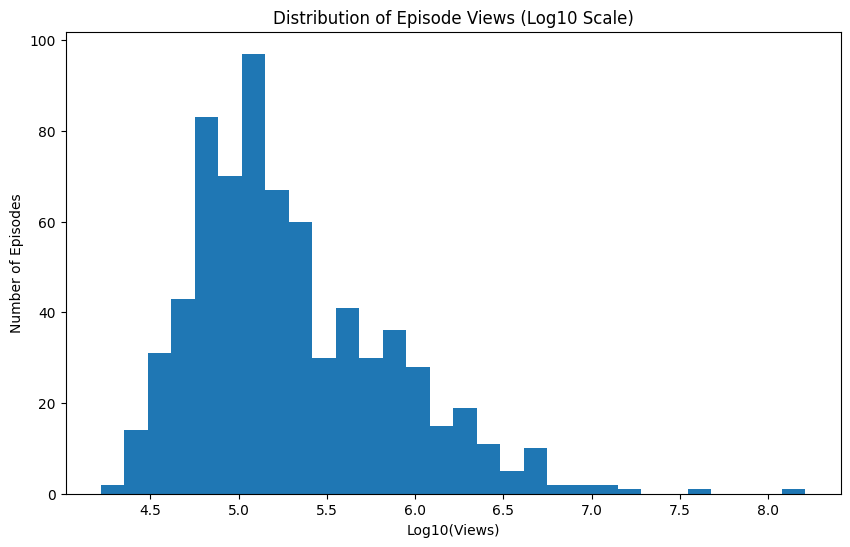

In [196]:
import numpy as np
import matplotlib.pyplot as plt

log_views = np.log10(df_clean["views"])

plt.figure(figsize=(10, 6))

plt.hist(log_views, bins=30)

plt.title("Distribution of Episode Views (Log10 Scale)")
plt.xlabel("Log10(Views)")
plt.ylabel("Number of Episodes")

plt.show()

### Observation

After applying the **log10 transformation**, the distribution of episode views becomes much clearer. Most episodes are concentrated within a relatively similar range of view counts, while a smaller number of episodes extend toward much higher values.

The transformed distribution still shows a **right tail**, indicating that a limited number of episodes achieved substantially higher reach than the majority. This supports the earlier observation that exceptionally high-view episodes strongly influence the average number of views.

## 4. Distribution of Likes

The distribution of likes was examined to understand how audience engagement through likes varies across the episodes and to identify possible skewness and extreme values.

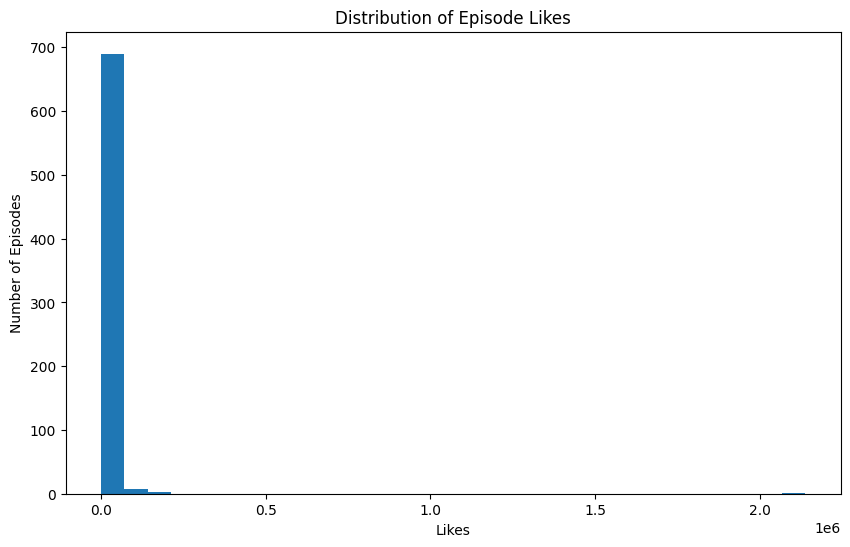

In [197]:
plt.figure(figsize=(10, 6))

plt.hist(df_clean["likes"], bins=30)

plt.title("Distribution of Episode Likes")
plt.xlabel("Likes")
plt.ylabel("Number of Episodes")

plt.show()

### Observation

The distribution of likes is **strongly right-skewed**. Most episodes receive relatively lower numbers of likes, while a small number of episodes have exceptionally high like counts.

The maximum reaches approximately **2.14 million likes**, which stretches the x-axis and makes the distribution of most episodes difficult to observe on the original scale. This pattern is consistent with the descriptive statistics, where the mean number of likes was substantially higher than the median.

### Likes Distribution Using Log Transformation

Because the original distribution is strongly right-skewed, a **log10 transformation** was applied to the like counts to provide a clearer representation of the distribution across episodes.

The transformation is used only for visualization and does not remove or modify any episodes in the original dataset.

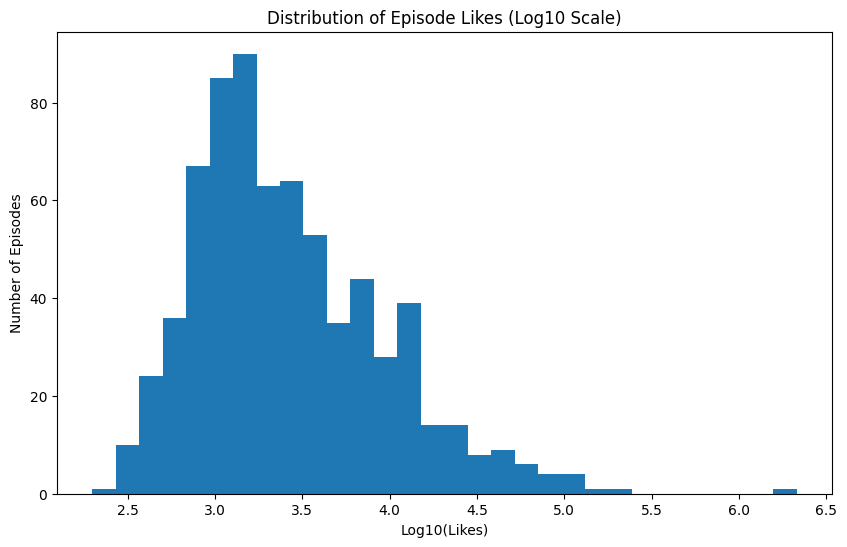

In [198]:
log_likes = np.log10(df_clean["likes"])

plt.figure(figsize=(10, 6))

plt.hist(log_likes, bins=30)

plt.title("Distribution of Episode Likes (Log10 Scale)")
plt.xlabel("Log10(Likes)")
plt.ylabel("Number of Episodes")

plt.show()

### Observation

After applying the **log10 transformation**, the distribution of likes becomes much clearer. Most episodes are concentrated within a similar range of like counts, while fewer episodes extend toward substantially higher values.

The distribution still shows a **right tail**, confirming that a relatively small number of episodes receive much higher numbers of likes than the majority. This explains why the mean number of likes is considerably higher than the median.

## 5. Distribution of Comments

The distribution of comments was examined to understand how audience interaction varies across episodes. Since the comment counts include zero values and a small number of extremely high values, a **log1p transformation** was used for visualization to provide a clearer representation of the overall distribution.

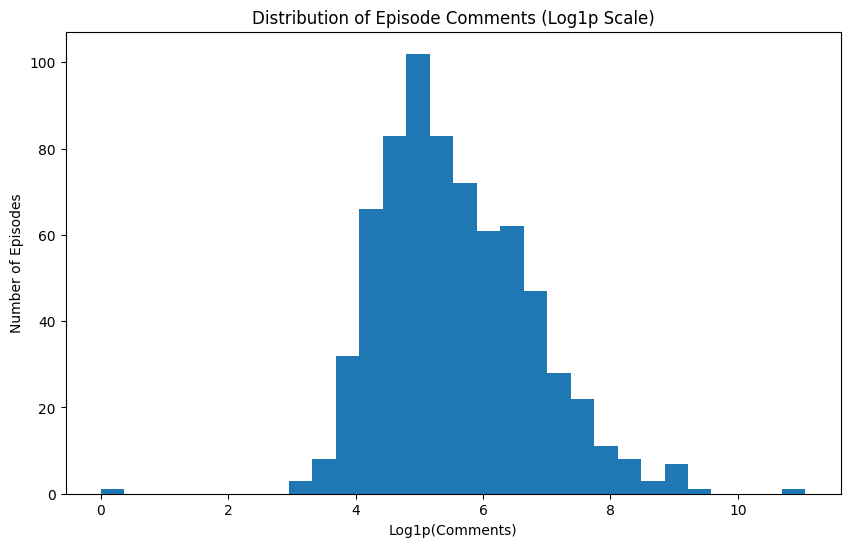

In [199]:
log_comments = np.log1p(df_clean["comments"])

plt.figure(figsize=(10, 6))

plt.hist(log_comments, bins=30)

plt.title("Distribution of Episode Comments (Log1p Scale)")
plt.xlabel("Log1p(Comments)")
plt.ylabel("Number of Episodes")

plt.show()

### Observation

The transformed distribution shows that most episodes are concentrated within a moderate range of comment activity, while a smaller number of episodes extend toward substantially higher values.

This is consistent with the descriptive statistics, where the mean number of comments (**672.90**) is considerably higher than the median (**216**), indicating a **right-skewed distribution**. The log1p transformation was used only to improve visualization and did not remove or modify any episodes in the original dataset.

## 6. Distribution of Episode Duration

The distribution of episode duration was examined to understand the typical length of Thmanyah podcast episodes and the variation in episode length across the dataset.

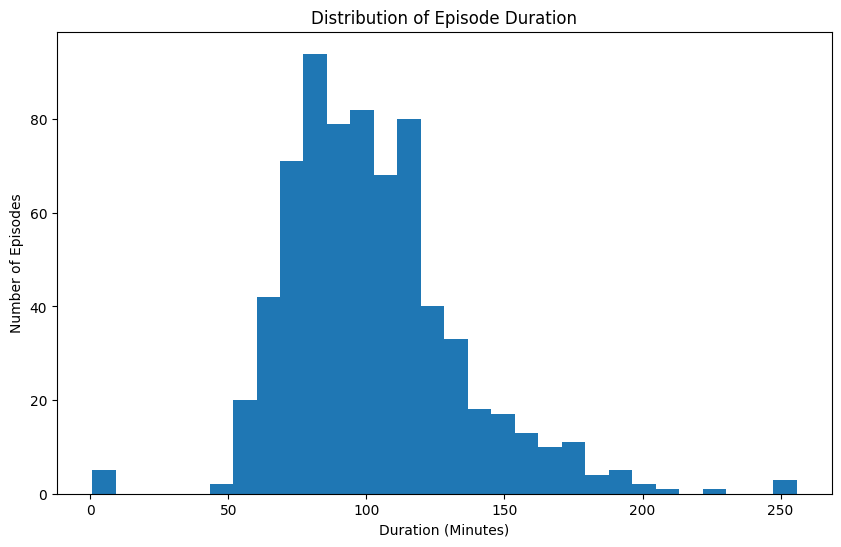

In [200]:
plt.figure(figsize=(10, 6))

plt.hist(df_clean["duration_minutes"], bins=30)

plt.title("Distribution of Episode Duration")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Episodes")

plt.show()

### Observation

Episode durations are mainly concentrated between approximately **70 and 120 minutes**, indicating that most episodes are relatively long-form. The number of episodes gradually decreases as duration increases beyond this range.

The mean duration (**102.47 minutes**) is slightly higher than the median (**97.75 minutes**), suggesting a **mild right-skewed distribution**. A small number of episodes have unusually short or long durations, including episodes exceeding **200 minutes**.

## 7. Distribution of Engagement Rate

The distribution of engagement rate was examined to understand how the level of audience interaction varies across episodes relative to their number of views.

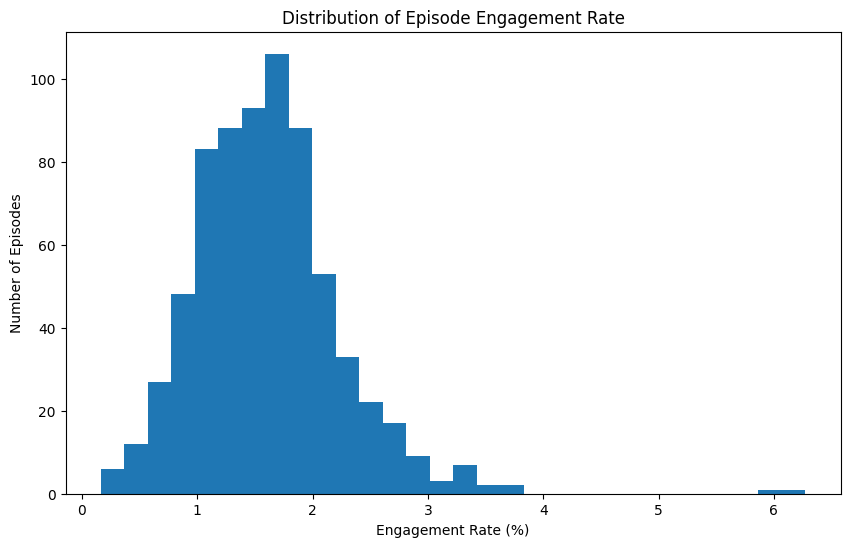

In [201]:
plt.figure(figsize=(10, 6))

plt.hist(df_clean["engagement_rate"], bins=30)

plt.title("Distribution of Episode Engagement Rate")
plt.xlabel("Engagement Rate (%)")
plt.ylabel("Number of Episodes")

plt.show()

### Observation

Most episodes have an engagement rate concentrated between approximately **1% and 2%**, indicating a relatively consistent level of audience interaction across the majority of episodes.

The mean engagement rate (**1.61%**) is close to the median (**1.58%**), suggesting that the distribution is relatively balanced compared with views, likes, and comments. However, a small number of episodes show higher engagement rates, including an extreme value of approximately **6.27%**, creating a slight right tail.

### Distribution Analysis Summary

The distribution analysis provided an overall understanding of how the main numerical variables behave across the dataset.

The analysis showed that **views, likes, and comments are strongly right-skewed**, where most episodes have relatively moderate values while a small number of episodes achieve exceptionally high reach and interaction. Log transformations were used when necessary to make these distributions easier to visualize without modifying the original data.

In contrast, **episode duration and engagement rate showed more balanced distributions**. Most episodes were concentrated around similar duration and engagement ranges, although a small number of extreme values were still observed.

Since the overall distributions and major patterns of the numerical variables have now been identified, the analysis can move from examining the dataset as a whole to comparing the four podcast programs individually.

## 8. Basic Comparison Across Podcasts

After examining the overall distributions, the four podcast programs were compared to identify differences in their typical audience reach and interaction.

Because **views, likes, and comments are strongly right-skewed**, the **median** was used for the podcast-level comparison. The median is less affected by exceptionally high-performing episodes and therefore provides a clearer representation of a typical episode within each podcast.

In [202]:
podcast_comparison = df_clean.groupby("podcast").agg(
    Median_Views=("views", "median"),
    Median_Likes=("likes", "median"),
    Median_Comments=("comments", "median"),
    Median_Engagement_Rate=("engagement_rate", "median"),
    Median_Duration=("duration_minutes", "median")
).round(2)

podcast_comparison

,Median_Views,Median_Likes,Median_Comments,Median_Engagement_Rate,Median_Duration
podcast,,,,,
Fanjan,478025.0,6157.0,666.0,1.68,112.38
Mortada,79276.0,1295.0,136.0,1.80,102.56
Socrates,130879.0,1212.0,139.0,1.13,92.37
Swalif Business,133948.0,2093.0,158.0,1.67,82.92


### Audience Reach and Relative Engagement Across Podcasts

Median views were used to compare the typical **audience reach** of each podcast. In addition, median engagement rate was examined to compare **audience interaction relative to the number of views**.

These two measures provide complementary perspectives: views represent how widely episodes are reached, while engagement rate reflects the relative level of audience interaction.

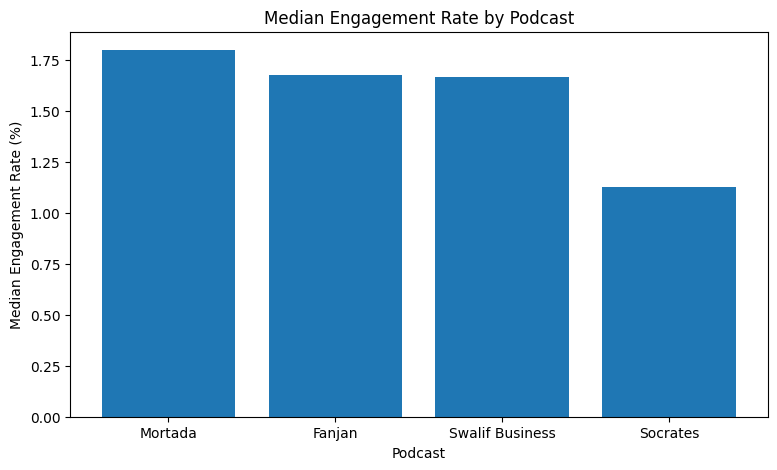

In [203]:
median_engagement = podcast_comparison["Median_Engagement_Rate"].sort_values(
    ascending=False
)

plt.figure(figsize=(9, 5))

plt.bar(median_engagement.index, median_engagement.values)

plt.title("Median Engagement Rate by Podcast")
plt.xlabel("Podcast")
plt.ylabel("Median Engagement Rate (%)")
plt.xticks(rotation=0)

plt.show()

### Key Observations

The podcast-level comparison reveals differences between **audience reach** and **relative audience engagement**.

- **Fanjan** has the highest typical audience reach, with a median of **478,025 views**, as well as the highest median likes (**6,157**) and comments (**666**).
- **Swalif Business** and **Socrates** have similar median view counts (**133,948** and **130,879**, respectively), although Swalif Business shows a higher median engagement rate (**1.67%**) than Socrates (**1.13%**).
- **Mortada** has the lowest median views (**79,276**), but the highest median engagement rate (**1.80%**).
- Fanjan and Swalif Business have very similar median engagement rates (**1.68%** and **1.67%**, respectively).

These findings show that **higher audience reach does not necessarily correspond to a higher engagement rate**. A podcast may reach fewer viewers while still generating a relatively high level of interaction among its audience.

# 9. Primary EDA Summary

The exploratory analysis provided an overview of audience reach, interaction, episode duration, and engagement across the selected Thmanyah podcasts.

The analysis showed that views, likes, and comments are strongly right-skewed, with a small number of episodes achieving exceptionally high values. In contrast, episode duration and engagement rate showed more balanced distributions.

Podcast-level comparisons also revealed differences between audience reach and relative engagement. Fanjan showed the highest typical reach, while Mortada had the highest median engagement rate despite having lower median views. This indicates that higher reach does not necessarily correspond to higher relative audience engagement.

These findings provide a descriptive foundation for the next stage of analysis, which will examine relationships between variables, correlations, and episode topics in greater detail.

## Correlation Analysis

A correlation matrix was used to examine the relationships between views, likes, comments, video duration, and engagement rate.

The results help identify whether these variables have positive or negative relationships and how strongly they are associated with each other.

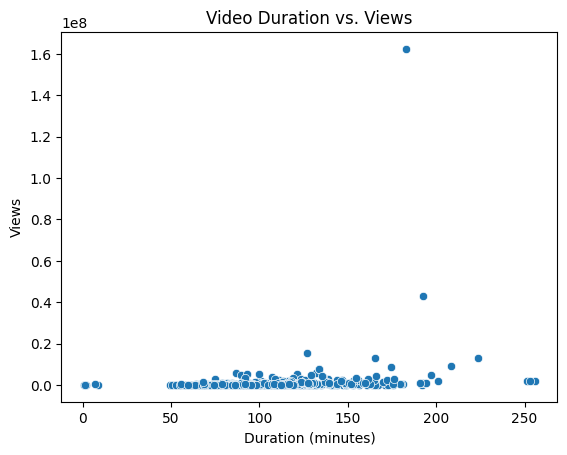

In [204]:
import seaborn as sns

sns.scatterplot(data=df_clean, x="duration_minutes", y="views")

plt.title("Video Duration vs. Views")
plt.xlabel("Duration (minutes)")
plt.ylabel("Views")
plt.show()

### Key Observations

The scatter plot shows the relationship between **video duration** and **audience reach**, measured by view counts.

- Most videos are approximately **50–180 minutes** long, with view counts concentrated toward the lower end of the scale.
- Videos of similar duration show different view counts, suggesting that **duration alone does not explain audience reach**.
- A few videos stand out with exceptionally high views. One video lasting approximately **185 minutes** reaches around **162 million views**, while another lasting approximately **195 minutes** reaches around **43 million views**.
- These extreme values compress the majority of points near the bottom of the plot, making the overall relationship harder to assess.

These findings show that **longer videos do not consistently receive more views**. Although some longer videos achieve exceptionally high reach, the plot does not show a clear, strong relationship between duration and views.

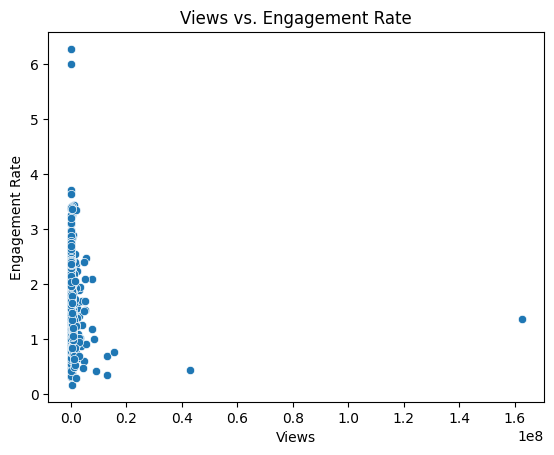

In [205]:
sns.scatterplot(data=df_clean, x="views", y="engagement_rate")

plt.title("Views vs. Engagement Rate")
plt.xlabel("Views")
plt.ylabel("Engagement Rate")
plt.show()

# Key Observations

The scatter plot compares audience reach, measured by views, with relative audience engagement.

Most videos are concentrated at lower view counts, with engagement rates generally below 4%.

Some videos with relatively low view counts achieve engagement rates of approximately 6%, showing that smaller audiences can still generate substantial relative interaction.

The most-viewed video, with approximately 162 million views, has an engagement rate of around 1.4%.

Videos with similar view counts show different engagement rates, and the plot does not reveal a clear, strong relationship between the two variables.

These findings show that higher audience reach does not necessarily correspond to a higher engagement rate. A video may attract fewer viewers while generating more interaction relative to its view count.

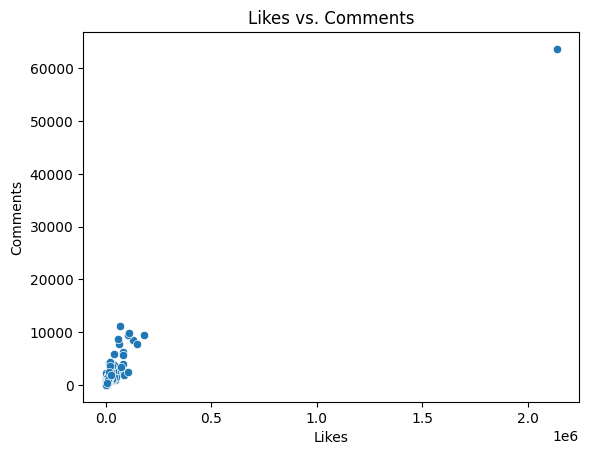

In [206]:
sns.scatterplot(data=df_clean, x="likes", y="comments")

plt.title("Likes vs. Comments")
plt.xlabel("Likes")
plt.ylabel("Comments")
plt.show()

### Key Observations

The scatter plot shows the relationship between **likes** and **comments**, representing two forms of audience interaction.

- Videos with more likes generally receive more comments, indicating a **positive association** between the two variables.
- Most videos are concentrated near the lower end of both scales, while relatively few receive exceptionally high interaction counts.
- One video stands out with approximately **2.1 million likes** and **64,000 comments**, far exceeding the other videos.
- Videos with similar like counts can receive different numbers of comments, suggesting variation in how audiences interact.
- The extreme observation stretches the axes and makes differences among the remaining videos harder to distinguish.

These findings suggest that **likes and comments tend to increase together**. However, the extreme observation may strongly influence the measured correlation, so examining the relationship with and without it would help assess how consistent this pattern is.

In [207]:
corr = df_clean[[
    "views",
    "likes",
    "comments",
    "duration_minutes",
    "engagement_rate"
]].corr()

corr

,views,likes,comments,duration_minutes,engagement_rate
views,1.000000,0.978678,0.949211,0.189607,-0.068680
likes,0.978678,1.000000,0.954447,0.148115,-0.016726
comments,0.949211,0.954447,1.000000,0.226619,-0.027521
duration_minutes,0.189607,0.148115,0.226619,1.000000,-0.349396
engagement_rate,-0.068680,-0.016726,-0.027521,-0.349396,1.000000


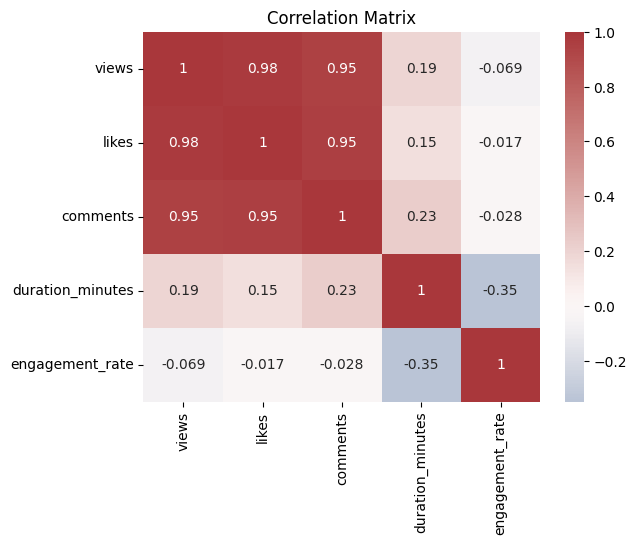

In [208]:
sns.heatmap(
    corr,
    annot=True,
    cmap="vlag",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

# Key Observations

The correlation matrix reveals relationships between audience reach, audience interaction, video duration, and engagement rate.

Views and likes have a very strong positive correlation (r = 0.979), indicating that videos with more views generally receive more likes.

Views and comments (r = 0.949) and likes and comments (r = 0.954) also show very strong positive correlations.

Video duration has weak positive correlations with views (r = 0.190), likes (r = 0.148), and comments (r = 0.227), suggesting a limited linear relationship with these metrics.

Duration and engagement rate show a moderate negative correlation (r = −0.349), suggesting that longer videos tend to have lower relative engagement.

Engagement rate has correlations close to zero with views (r = −0.069), likes (r = −0.017), and comments (r = −0.028), indicating little linear association.

These findings show that higher view counts are closely associated with more likes and comments, but not necessarily with higher engagement rates. These correlations describe associations rather than causation and may be influenced by exceptionally popular videos.

**Title Cleaning for Text Analysis**

In [209]:
def clean_title(title):
    title = str(title)

    # Remove podcast name after |
    title = title.split("|")[0]

    # Remove punctuation and numbers
    title = re.sub(r'[^\u0600-\u06FF\s]', '', title)

    # Remove extra spaces
    title = re.sub(r'\s+', ' ', title).strip()

    return title

df_clean["clean_title"] = df_clean["title"].apply(clean_title)

In [210]:
arabic_stopwords = [
    "في", "من", "إلى", "على", "عن", "ما", "ماذا",
    "كيف", "هل", "لماذا", "مع", "هذا", "هذه",
    "التي", "الذي", "بعد", "قبل", "كل", "بين",
    "أو", "ولا", "هو", "هي",

]

words = " ".join(df_clean["clean_title"]).split()

words = [
    word for word in words
    if word not in arabic_stopwords and len(word) > 2
]

We combined words from the cleaned titles and removed common Arabic stopwords, podcast names, and words shorter than three characters to focus on meaningful terms.

**Podcast Title Word Frequency and N-gram Analysis**

In [211]:
from collections import Counter

word_counts = Counter(words)

word_counts.most_common(30)

[('السعودية', 60),
 ('سالفة', 43),
 ('الهلال', 36),
 ('التنفيذي', 35),
 ('الرئيس', 34),
 ('فنجان', 32),
 ('بودكاست', 30),
 ('السعودي', 26),
 ('الاتحاد', 23),
 ('بزنس', 22),
 ('رئيس', 18),
 ('العالم', 18),
 ('النصر', 16),
 ('منصة', 13),
 ('وزير', 12),
 ('العامة', 12),
 ('تجربة', 11),
 ('متى', 11),
 ('الملك', 11),
 ('العربي', 11),
 ('العام', 11),
 ('الأهلي', 11),
 ('الشركات', 10),
 ('المالية', 10),
 ('شركة', 9),
 ('إدارة', 9),
 ('الرياض', 9),
 ('الشباب', 9),
 ('الخليج', 9),
 ('والنصر', 9)]

In [212]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    ngram_range=(2, 2),
    max_features=30
)

X = vectorizer.fit_transform(df_clean["clean_title"])

vectorizer.get_feature_names_out()

array(['الأمين العام', 'التنفيذي لبرنامج', 'التنفيذي لشركة',
       'التنفيذي للشركة', 'التنفيذي لهيئة', 'الذكاء الاصطناعي',
       'الرئيس التنفيذي', 'السعودية مع', 'الموارد البشرية',
       'الهيئة العامة', 'بودكاست فنجان', 'رئيس مجلس', 'سالفة بزنس',
       'سالفة منصة', 'في السعودية', 'كأس العالم', 'كيف تستفيد',
       'كيف تعمل', 'كيف غيرت', 'للشركة السعودية', 'مجلس إدارة',
       'مع الأمين', 'مع الرئيس', 'مع خالد', 'مع رئيس', 'مع محافظ',
       'مع محمد', 'مع نائب', 'مع وزير', 'نائب وزير'], dtype=object)

# Observation:
Observation:
The initial n-gram results included many common phrases related to podcast names and guest job titles, such as بودكاست فنجان، سالفة بزنس، الرئيس التنفيذي، and نائب وزير. These phrases do not clearly represent the actual podcast topics. Therefore, additional stopwords were added to remove podcast-specific words, common job titles, and general Arabic words. This helps the n-gram analysis focus on more meaningful topic-related phrases.

In [213]:
arabic_stopwords = [
    # General Arabic stopwords
    "في", "من", "إلى", "على", "عن", "ما", "ماذا",
    "كيف", "هل", "لماذا", "مع", "هذا", "هذه",
    "التي", "الذي", "بعد", "قبل", "كل", "بين",
    "أو", "ولا", "هو", "هي", "متى",

    # Podcast-specific words
    "بودكاست", "فنجان", "سالفة", "بزنس",

    # Job titles / common interview words
    "الرئيس", "رئيس", "التنفيذي", "وزير", "نائب",
    "الأمين", "العام", "محافظ"
]

words = " ".join(df_clean["clean_title"]).split()

words = [
    word for word in words
    if word not in arabic_stopwords and len(word) > 2
]

In [214]:

word_counts = Counter(words)

word_counts.most_common(30)

[('السعودية', 60),
 ('الهلال', 36),
 ('السعودي', 26),
 ('الاتحاد', 23),
 ('العالم', 18),
 ('النصر', 16),
 ('منصة', 13),
 ('العامة', 12),
 ('تجربة', 11),
 ('الملك', 11),
 ('العربي', 11),
 ('الأهلي', 11),
 ('الشركات', 10),
 ('المالية', 10),
 ('شركة', 9),
 ('إدارة', 9),
 ('الرياض', 9),
 ('الشباب', 9),
 ('الخليج', 9),
 ('والنصر', 9),
 ('الاصطناعي', 8),
 ('تحديات', 8),
 ('كواليس', 8),
 ('الوطني', 8),
 ('كأس', 8),
 ('والهلال', 8),
 ('الذكاء', 7),
 ('تطبيق', 7),
 ('سوق', 7),
 ('تجارب', 7)]

In [215]:

vectorizer = CountVectorizer(
    ngram_range=(2, 2),
    max_features=30,
    stop_words=arabic_stopwords
)

X = vectorizer.fit_transform(df_clean["clean_title"])

vectorizer.get_feature_names_out()

array(['الإعلام العربي', 'البلدية والقروية', 'الخطوط السعودية',
       'الذكاء الاصطناعي', 'الشؤون البلدية', 'الشركة السعودية',
       'الصحة النفسية', 'المؤسسة العامة', 'الملك سلمان',
       'الملك عبدالعزيز', 'المنتخب السعودي', 'الموارد البشرية',
       'الهيئة العامة', 'حياة الإدارة', 'كأس العالم', 'للشركة السعودية',
       'للمركز الوطني', 'للهيئة العامة', 'لم ننجح', 'لمركز الملك',
       'مالك الروقي', 'مجلس إدارة', 'محمد قاسم', 'مساعد المالية',
       'مشهور الدبيان', 'والثروة المعدنية', 'والقروية والإسكان',
       'والهلال يواصل', 'يرفض الهدية', 'يكسب الشباب'], dtype=object)

# Observation:
After removing the additional stopwords, the frequent words and bigrams became more related to the actual podcast content. The results show recurring themes such as sports, business, technology, health, and Saudi-related topics. For example, phrases such as الذكاء الاصطناعي، الصحة النفسية، الموارد البشرية، كأس العالم, and مجلس إدارة appeared frequently. These results helped identify the main topic categories used in the topic classification.

**Top 15 Most Frequent Bigrams**

In [216]:

bigram_counts = np.asarray(X.sum(axis=0)).flatten()

bigram_df = pd.DataFrame({
    "bigram": vectorizer.get_feature_names_out(),
    "count": bigram_counts
})

bigram_df = bigram_df.sort_values(
    by="count",
    ascending=False
)

bigram_df.head(15)

,bigram,count
3,الذكاء الاصطناعي,7
21,مجلس إدارة,5
11,الموارد البشرية,4
16,للمركز الوطني,4
14,كأس العالم,4
12,الهيئة العامة,4
15,للشركة السعودية,4
4,الشؤون البلدية,3
6,الصحة النفسية,3
7,المؤسسة العامة,3


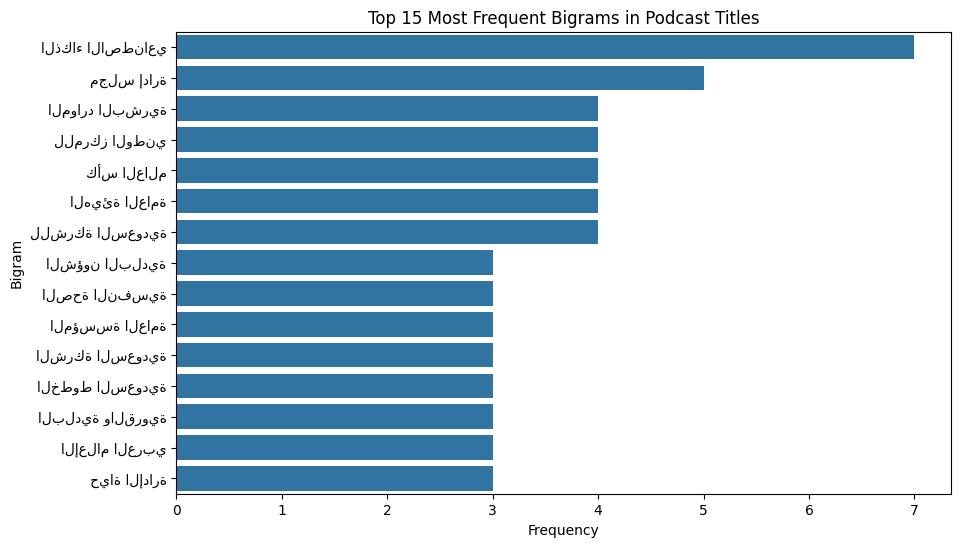

In [217]:
top_bigrams = bigram_df.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_bigrams,
    x="count",
    y="bigram"
)

plt.title("Top 15 Most Frequent Bigrams in Podcast Titles")
plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.show()

# Observation:

The most frequent bigram was الذكاء الاصطناعي, appearing 7 times, followed by مجلس إدارة with 5 occurrences. Other recurring phrases include الموارد البشرية، كأس العالم، الصحة النفسية, and الإعلام العربي. These bigrams indicate recurring topics related to technology, business, sports, health, and media, which helped in defining the topic categories for further analysis.

**Topic Classification Based on Title Keywords**

Method:
Based on the frequent words and bigrams identified in the previous analysis, topic categories and related keywords were defined. Each podcast title was then assigned to a topic based on the presence of these keywords. Titles that did not match any of the predefined categories were classified as Other.

In [218]:
def classify_topic(title):
    title = str(title).lower()

    # Sports
    if any(word in title for word in [
        "الهلال", "الاتحاد", "النصر", "الأهلي", "الشباب",
        "المنتخب", "كأس العالم", "الدوري", "الكرة",
        "مباراة", "بطولة", "رياضة", "رياضي"
    ]):
        return "Sports"

    # Business & Finance
    elif any(word in title for word in [
        "شركة", "الشركات", "إدارة", "مالية", "المالية",
        "استثمار", "تمويل", "السوق", "تجارة", "تجارية",
        "العملاء", "الموارد البشرية", "الرئيس التنفيذي",
        "مجلس إدارة", "مشروع", "الأعمال"
    ]):
        return "Business & Finance"

    # Technology
    elif any(word in title for word in [
        "الذكاء الاصطناعي", "تقنية", "التقنية",
        "برمجة", "البرمجة", "منصة", "رقمية",
        "تطبيق", "البيانات", "الإنترنت"
    ]):
        return "Technology"

    # Health
    elif any(word in title for word in [
        "الصحة", "الصحة النفسية", "مرض", "العلاج",
        "طبيب", "الطب", "نفسي", "الاكتئاب",
        "التوحد", "وزن", "الغذاء", "النوم"
    ]):
        return "Health"

    # Politics & Government
    elif any(word in title for word in [
        "وزير", "وزارة", "الهيئة", "الحكومة",
        "سياسة", "سياسي", "الدولة", "الحرب",
        "الاحتلال", "حكم", "العلاقات الدولية"
    ]):
        return "Politics & Government"

    # History & Culture
    elif any(word in title for word in [
        "تاريخ", "التاريخ", "الملك عبدالعزيز",
        "الملك سلمان", "تراث", "ثقافة", "الثقافة",
        "العرب", "حضارة"
    ]):
        return "History & Culture"

    # Religion
    elif any(word in title for word in [
        "القرآن", "الصلاة", "الإسلام", "الدين",
        "الله", "المسلمين", "العبادة", "الإيمان"
    ]):
        return "Religion"

    # Media
    elif any(word in title for word in [
        "الإعلام", "الأخبار", "صحافة", "الصحافة",
        "المحتوى", "قناة", "التلفزيون"
    ]):
        return "Media"

    else:
        return "Other"


df_clean["topic"] = df_clean["clean_title"].apply(classify_topic)

In [219]:
df_clean["topic"].value_counts()

,count
topic,
Other,365
Business & Finance,102
Sports,94
History & Culture,40
Technology,37
Politics & Government,34
Health,14
Religion,11
Media,4


## Observation:
The topic classification shows that Other is the largest category with 365 videos, indicating that many titles could not be clearly classified using the predefined keywords. Among the identified topics, Business & Finance and Sports were the most common, with 102 and 94 videos respectively. Other topics such as History & Culture, Technology, and Politics & Government appeared less frequently, while Media had the smallest number of videos.

**Analysis of Unclassified Titles (Other)**

In [220]:
other_titles = df_clean[df_clean["topic"] == "Other"]["clean_title"]

other_words = " ".join(other_titles).split()

other_words = [
    word for word in other_words
    if word not in arabic_stopwords and len(word) > 2
]

Counter(other_words).most_common(40)

[('السعودية', 34),
 ('العالم', 10),
 ('تجربة', 9),
 ('الرياض', 8),
 ('الخليج', 7),
 ('السعودي', 7),
 ('تأسيس', 6),
 ('كواليس', 6),
 ('محمد', 6),
 ('تصميم', 5),
 ('غيرت', 5),
 ('سوق', 5),
 ('تغير', 5),
 ('تجارب', 5),
 ('المطاعم', 5),
 ('مشكلة', 5),
 ('الاقتصاد', 5),
 ('العامة', 5),
 ('تفشل', 4),
 ('قصة', 4),
 ('مطعم', 4),
 ('عسير', 4),
 ('فعلًا', 4),
 ('الحياة', 4),
 ('خلف', 4),
 ('المستقبل', 4),
 ('رحلة', 3),
 ('تحديات', 3),
 ('تتجنب', 3),
 ('واقع', 3),
 ('تنجح', 3),
 ('متجر', 3),
 ('ضيوف', 3),
 ('سوالف', 3),
 ('وبيع', 3),
 ('أداء', 3),
 ('صناعة', 3),
 ('العمل', 3),
 ('أسعار', 3),
 ('حياة', 3)]

In [221]:
other_vectorizer = CountVectorizer(
    ngram_range=(2, 2),
    max_features=30,
    stop_words=arabic_stopwords
)

X_other = other_vectorizer.fit_transform(other_titles)

other_bigram_counts = np.asarray(X_other.sum(axis=0)).flatten()

other_bigram_df = pd.DataFrame({
    "bigram": other_vectorizer.get_feature_names_out(),
    "count": other_bigram_counts
})

other_bigram_df.sort_values(
    by="count",
    ascending=False
).head(20)

,bigram,count
4,الخطوط السعودية,3
7,المؤسسة العامة,3
1,أن تعيش,2
2,اقتصاد الخليج,2
3,الحياة السعودية,2
0,أمين منطقة,2
5,الدعاية والإعلان,2
6,السبب خلف,2
8,المصرفية المفتوحة,2
9,تجربة تأسيس,2


Observation:
The analysis of the Other category revealed additional recurring themes that were not fully captured by the initial topic keywords. Terms related to economics and business appeared frequently, such as الاقتصاد، سوق، أسعار، تأسيس, and المطاعم. Based on these results, the topic keywords were refined and an Economics category was added to improve the classification.

In [222]:
def classify_other(title):
    title = str(title).lower()

    # Business & Finance
    if any(word in title for word in [
        "تأسيس", "سوق", "المطاعم", "مطعم",
        "متجر", "صناعة", "العمل",
        "المصرفية", "المصرفية المفتوحة"
    ]):
        return "Business & Finance"

    # Economics
    elif any(word in title for word in [
        "الاقتصاد", "اقتصاد", "أسعار",
        "اقتصاد الخليج"
    ]):
        return "Economics"

    # Society & Personal Development
    elif any(word in title for word in [
        "الحياة", "حياة", "تجربة", "تجارب",
        "تنجح", "تفشل", "تحديات",
        "أن تعيش"
    ]):
        return "Society & Personal Development"

    # Media
    elif any(word in title for word in [
        "الدعاية", "الإعلان", "الدعاية والإعلان"
    ]):
        return "Media"

    else:
        return "Other"


# Apply only to videos currently classified as Other
mask = df_clean["topic"] == "Other"

df_clean.loc[mask, "topic"] = (
    df_clean.loc[mask, "clean_title"].apply(classify_other)
)

# Display updated topic counts
df_clean["topic"].value_counts()

,count
topic,
Other,286
Business & Finance,135
Sports,94
History & Culture,40
Technology,37
Politics & Government,34
Society & Personal Development,33
Health,14
Economics,12


# Observation:

After refining the topic classification using the frequent words and bigrams found in the Other category, the final classification resulted in 11 topic categories. Business & Finance was the largest identified topic with 135 videos, followed by Sports with 94 videos. The Other category contained 286 videos that could not be reliably assigned to the predefined topics, so they were kept unclassified to avoid forcing inaccurate classifications.

**Topic-Based Comparison**

The final topic categories were compared based on reach, engagement, and video duration. Average views, likes, comments, engagement rate, and duration were calculated for each topic.

In [224]:
topic_analysis = df_clean.groupby("topic").agg(
    number_of_videos=("video_id", "count"),
    avg_views=("views", "mean"),
    avg_likes=("likes", "mean"),
    avg_comments=("comments", "mean"),
    avg_engagement_rate=("engagement_rate", "mean"),
    avg_duration=("duration_minutes", "mean")
).round(2)

topic_analysis.sort_values("avg_views", ascending=False)

,number_of_videos,avg_views,avg_likes,avg_comments,avg_engagement_rate,avg_duration
topic,,,,,,
Society & Personal Development,33,5220094.94,68245.67,2257.64,1.62,100.27
History & Culture,40,1611578.38,11524.12,1266.97,1.65,115.27
Health,14,1097981.79,20656.93,968.57,1.93,109.32
Other,286,831013.18,9595.62,758.12,1.61,103.37
Religion,11,770062.45,10236.73,1019.09,1.42,111.69
Politics & Government,34,642166.91,6516.62,740.12,1.34,115.23
Economics,12,585002.00,6258.00,783.50,1.24,112.36
Business & Finance,135,257555.10,3338.34,278.90,1.49,93.16
Technology,37,254023.35,4163.86,302.97,1.86,95.01


**Average Views by Topic**

This visualization compares the average number of views across the different podcast topics to examine how audience reach varies by topic.

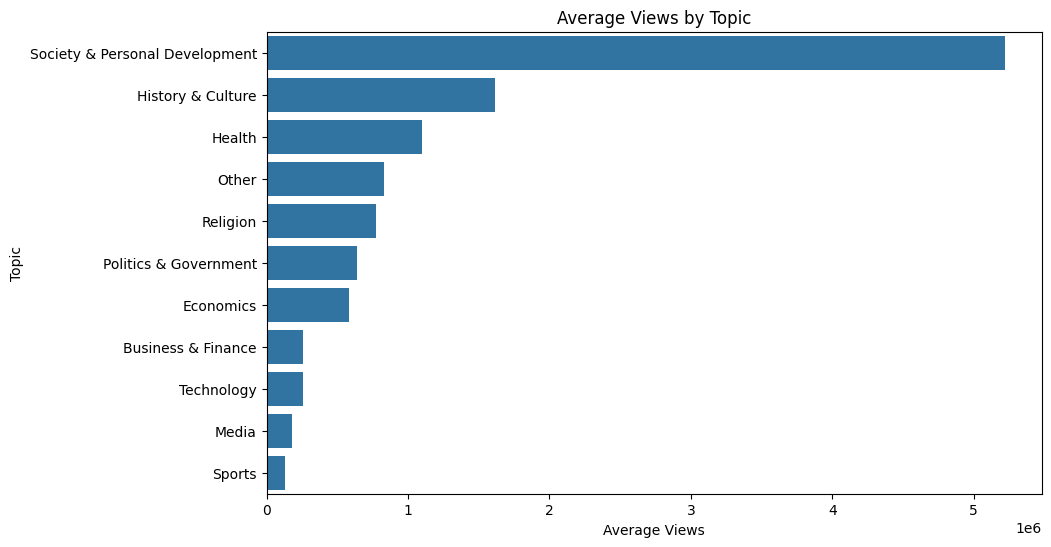

In [225]:
views_by_topic = (
    df_clean.groupby("topic")["views"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=views_by_topic.values,
    y=views_by_topic.index
)

plt.title("Average Views by Topic")
plt.xlabel("Average Views")
plt.ylabel("Topic")
plt.show()

## Observation
Society & Personal Development had the highest average views, exceeding 5 million views, followed by History & Culture and Health. In contrast, Sports, Media, Technology, and Business & Finance had much lower average views. This indicates that audience reach varies considerably across podcast topics.

**Average Views by Topic**

This visualization compares the average number of views across the different podcast topics to examine how audience reach varies by topic.

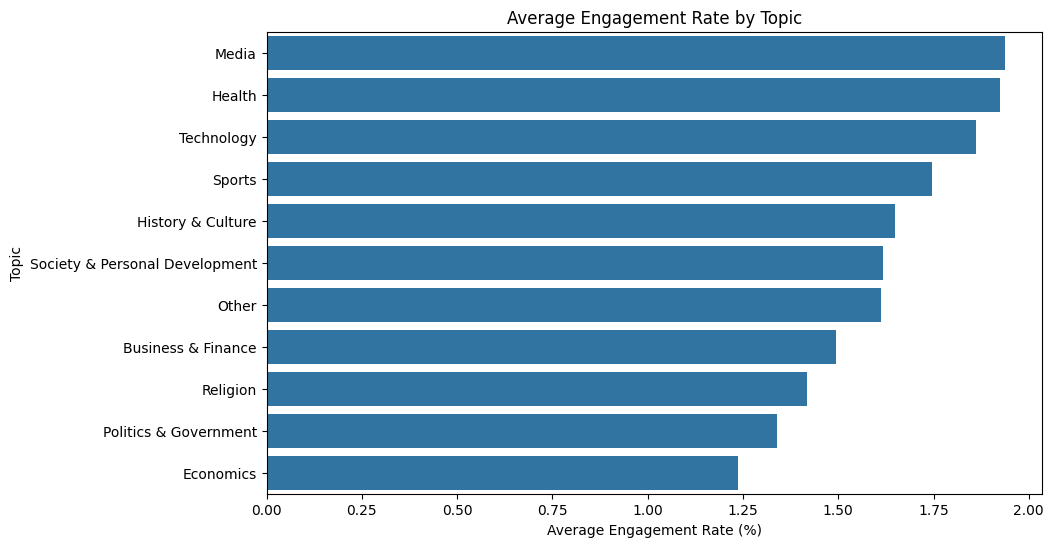

In [226]:
engagement_by_topic = (
   df_clean.groupby("topic")["engagement_rate"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=engagement_by_topic.values,
    y=engagement_by_topic.index
)

plt.title("Average Engagement Rate by Topic")
plt.xlabel("Average Engagement Rate (%)")
plt.ylabel("Topic")
plt.show()

## Observation

Media had the highest average engagement rate, followed closely by Health and Technology. Economics had the lowest average engagement rate. Interestingly, some topics with relatively low average views, such as Media and Technology, showed high engagement rates. This suggests that higher audience reach does not necessarily result in higher audience engagement.

**Median Views by Topic**

Since average views can be affected by videos with extremely high view counts, the median views were also calculated for each topic. This provides a more representative comparison of the typical number of views across topics.

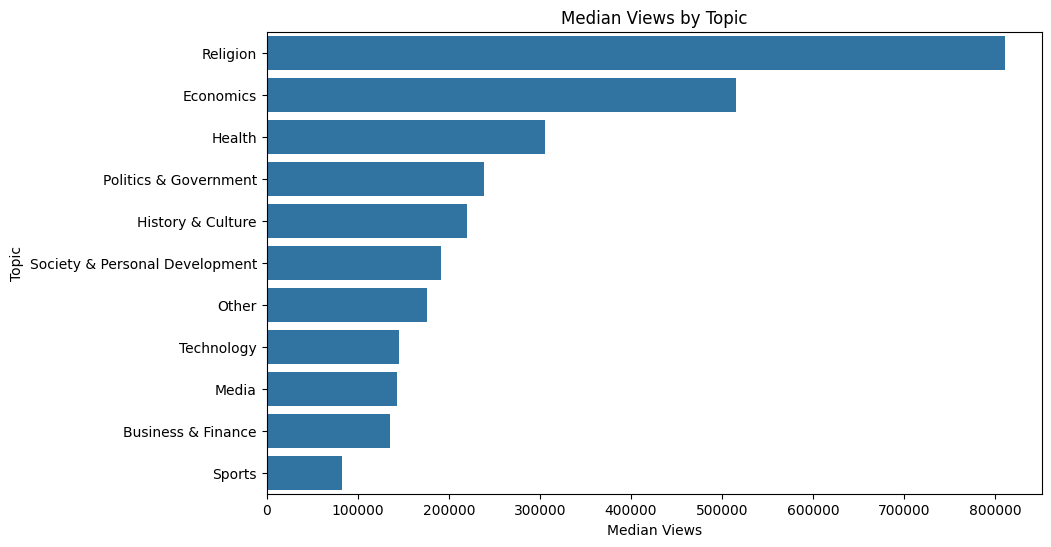

In [227]:
median_views = (
    df_clean.groupby("topic")["views"]
    .median()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=median_views.values,
    y=median_views.index
)

plt.title("Median Views by Topic")
plt.xlabel("Median Views")
plt.ylabel("Topic")
plt.show()

## Observation

The median views show a different pattern from the average views. Religion had the highest median views, followed by Economics and Health, while Sports had the lowest. Society & Personal Development, which had the highest average views, ranked lower when using the median. This suggests that its high average views may be influenced by a small number of highly viewed videos.

## Primary EDA and Topic Analysis Summary

The analysis examined the relationships between podcast performance metrics and explored how different topics vary in reach and audience engagement.

The correlation analysis showed strong positive relationships between **views, likes, and comments**, while episode duration had a weaker relationship with audience reach and engagement.

Podcast titles were analyzed using **word frequency and n-grams** to identify common themes. After removing general words, podcast names, and common job titles, the results highlighted recurring themes such as **business, sports, technology, health, and Saudi-related topics**. These patterns were then used to classify the episodes into topic categories.

The topic-based comparison showed clear differences in audience performance. **Society & Personal Development had the highest average views**, while **Media, Health, and Technology had the highest average engagement rates**. The median analysis showed a different pattern, with **Religion having the highest median views**, suggesting that some average values were influenced by a small number of highly viewed episodes.

Overall, the analysis showed that podcast topics vary in both **reach and audience engagement**, and topics with higher average views do not necessarily have higher engagement rates.